# Weighted GNN com pesos nas arestas

Notebook mínimo para treinar uma GNN cujos pesos das arestas são definidos por

$$w_{ij} = e^{-\lVert x_i - x_j \rVert_2},$$

onde $x_i$ e $x_j$ são as coordenadas dos nós. A topologia é construída por k-vizinhos mais próximos e a matriz ponderada é normalizada antes da propagação.

## 1. Bibliotecas e caminhos

In [1]:
import copy
import itertools
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import xarray as xr
from IPython.display import display
from sklearn.neighbors import NearestNeighbors


# Funciona tanto com o Jupyter iniciado na raiz quanto em Notebooks/.
project_dir = Path.cwd().resolve()
if project_dir.name.lower() == "notebooks":
    project_dir = project_dir.parent

src_dir = project_dir / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from Data.feature_extraction import (
    daily_precip_dataset_to_tensor,
    daily_temp_features,
    daily_vertical_velocity,
    forecast_steps_to_daily_precip,
    get_temp,
    get_vv,
    station_dictionary,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cpu


## 2. Carregamento e preparação dos dados

In [2]:
start_date = "2024-01-01"
end_date = "2025-05-31"

catalog_dir = project_dir / "Datasets" / "dados_inmet"
catalog_files = sorted(catalog_dir.glob("Catalogo*.csv"))
if not catalog_files:
    raise FileNotFoundError(f"Catálogo de estações não encontrado em {catalog_dir}")

catalogo_inmet = pd.read_csv(catalog_files[0], sep=";")
estacoes_RS = station_dictionary(catalogo_inmet)
estacoes = list(estacoes_RS.keys())

coords = np.asarray(
    [[float(lat), float(lon)] for lat, lon in estacoes_RS.values()],
    dtype=np.float32,
)
N = len(estacoes)

nc_dir = project_dir / "Datasets" / "nc_files"
rea_tp = xr.open_dataset(nc_dir / "era5_precipitation_80-26.nc").sel(
    time=slice(start_date, end_date)
)
rea_temp = xr.open_dataset(nc_dir / "temp_05-25.nc").sel(
    time=slice(start_date, end_date)
)
rea_vv = xr.open_dataset(nc_dir / "era5_vv_06-25.nc").sel(
    time=slice(start_date, end_date)
)

vv_daily_dataset = daily_vertical_velocity(rea_vv, var_name="w")
temp_daily_dataset = daily_temp_features(rea_temp)
tp_daily_dataset = forecast_steps_to_daily_precip(
    rea_tp,
    to_mm=True,
).isel(time=slice(None, -1))

T = (pd.Timestamp(end_date) - pd.Timestamp(start_date)).days + 1
X_tp = daily_precip_dataset_to_tensor(
    tp_daily_dataset,
    stations=estacoes_RS,
).reshape(T, N, 1)
X_t = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)
X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

print(f"Período: {start_date} a {end_date}")
print(f"Número de nós: {N}")

Período: 2024-01-01 a 2025-05-31
Número de nós: 62


## 3. Grade de hiperparâmetros e divisão dos nós

In [26]:
SEED = 42
node_index = 32
patience = 50
min_delta = 1e-4

# Grade editável de hiperparâmetros.
hyperparameter_grid = {
    "k": [3],
    "epochs": [2000],
    "hidden_dim": [64, 128, 256],
    "n_hidden_layers": [2],
    "learning_rate": [1e-3],
}

target_date = "2024-05-12"

# Target_dates: 

# Muita chuva: 12/05/2024
# Média chuva: 17/01/2024
# Pouca chuva: 12/01/2025
# Zero chuva: 08/02/2025

In [27]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

target_timestamp = pd.Timestamp(target_date)
if not pd.Timestamp(start_date) <= target_timestamp <= pd.Timestamp(end_date):
    raise ValueError("target_date está fora do período carregado.")

t_idx = (target_timestamp - pd.Timestamp(start_date)).days
X = torch.stack(
    [X_vv[t_idx, :, 0], X_t[t_idx, :, 0]],
    dim=-1,
).float()
y = X_tp[t_idx, :, 0].float()

generator = torch.Generator().manual_seed(SEED)
permutation = torch.randperm(N, generator=generator)
n_train = int(round(0.70 * N))
n_val = int(round(0.10 * N))

idx_train = permutation[:n_train]
idx_val = permutation[n_train:n_train + n_val]
idx_test = permutation[n_train + n_val:]


def make_mask(indices, size):
    mask = torch.zeros(size, dtype=torch.bool)
    mask[indices] = True
    return mask


mask_train = make_mask(idx_train, N)
mask_val = make_mask(idx_val, N)
mask_test = make_mask(idx_test, N)

X = X.to(device)
y = y.to(device)
mask_train = mask_train.to(device)
mask_val = mask_val.to(device)
mask_test = mask_test.to(device)

print(
    f"Treino: {mask_train.sum().item()} | "
    f"Validação: {mask_val.sum().item()} | "
    f"Teste: {mask_test.sum().item()}"
)

Treino: 43 | Validação: 6 | Teste: 13


## 4. Grafo ponderado

A matriz binária define apenas a topologia k-NN. Para cada aresta existente, o peso bruto é $e^{-\lVert x_i-x_j\rVert_2}$. Os auto-laços recebem peso 1 e, em seguida, é aplicada a normalização simétrica $D^{-1/2}AD^{-1/2}$.

In [28]:
def build_weighted_adjacency(coordinates, n_neighbors):
    """Constrói A e D^(-1/2) A D^(-1/2) com w_ij = exp(-||x_i-x_j||)."""
    coordinates = np.asarray(coordinates, dtype=np.float32)
    n_nodes = coordinates.shape[0]

    if not 1 <= n_neighbors < n_nodes:
        raise ValueError(f"k deve estar entre 1 e {n_nodes - 1}.")

    neighbors = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(coordinates)
    _, neighbor_indices = neighbors.kneighbors(coordinates)
    neighbor_indices = neighbor_indices[:, 1:]

    adjacency_binary = torch.zeros((n_nodes, n_nodes), dtype=torch.bool)
    for i, indices in enumerate(neighbor_indices):
        adjacency_binary[i, torch.as_tensor(indices, dtype=torch.long)] = True

    # Grafo não direcionado: basta que i escolha j ou j escolha i.
    adjacency_binary = adjacency_binary | adjacency_binary.T
    adjacency_binary.fill_diagonal_(False)

    coordinates_tensor = torch.as_tensor(coordinates, dtype=torch.float32)
    distances = torch.cdist(coordinates_tensor, coordinates_tensor, p=2)

    adjacency_weighted = torch.zeros_like(distances)
    adjacency_weighted[adjacency_binary] = torch.exp(
        -distances[adjacency_binary]
    )
    adjacency_weighted.fill_diagonal_(1.0)

    degree = adjacency_weighted.sum(dim=1).clamp_min(1e-12)
    inv_sqrt_degree = degree.rsqrt()
    adjacency_normalized = (
        inv_sqrt_degree[:, None]
        * adjacency_weighted
        * inv_sqrt_degree[None, :]
    )

    if not torch.isfinite(adjacency_normalized).all():
        raise FloatingPointError("A matriz ponderada contém valores não finitos.")

    return adjacency_weighted, adjacency_normalized


print("Regra de peso da grade: w_ij = exp(-||x_i - x_j||_2)")

Regra de peso da grade: w_ij = exp(-||x_i - x_j||_2)


## 5. Modelo

In [29]:
class WeightedGNN(nn.Module):
    """GNN densa com agregação pela adjacência ponderada normalizada."""

    def __init__(self, in_dim, hidden_dim, n_hidden_layers, out_dim=1):
        super().__init__()
        if n_hidden_layers < 1:
            raise ValueError("n_hidden_layers deve ser pelo menos 1.")

        self.hidden_layers = nn.ModuleList(
            [nn.Linear(in_dim, hidden_dim)]
            + [
                nn.Linear(hidden_dim, hidden_dim)
                for _ in range(n_hidden_layers - 1)
            ]
        )
        self.output_layer = nn.Linear(hidden_dim, out_dim)

    def forward(self, features, adjacency_normalized):
        hidden = features
        for layer in self.hidden_layers:
            hidden = adjacency_normalized @ hidden
            hidden = F.relu(layer(hidden))
        return self.output_layer(hidden).squeeze(-1)

## 6. Busca em grade com early stopping

In [30]:
import itertools


def train_weighted_gnn(
    features,
    targets,
    adjacency_normalized,
    train_mask,
    val_mask,
    test_mask,
    epochs_value,
    hidden_dim_value,
    n_hidden_layers_value,
    learning_rate_value,
    patience_value,
    min_delta_value,
    seed=42,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = WeightedGNN(
        in_dim=features.shape[1],
        hidden_dim=hidden_dim_value,
        n_hidden_layers=n_hidden_layers_value,
    ).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate_value,
    )
    loss_function = nn.MSELoss(reduction="mean")

    history = {"train": [], "validation": [], "test": []}
    best_validation = float("inf")
    best_epoch = 0
    stop_epoch = epochs_value
    patience_counter = 0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs_value + 1):
        model.train()
        optimizer.zero_grad()
        predictions = model(features, adjacency_normalized)
        train_loss = loss_function(predictions[train_mask], targets[train_mask])
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            predictions = model(features, adjacency_normalized)
            validation_loss = loss_function(
                predictions[val_mask], targets[val_mask]
            )
            test_loss = loss_function(predictions[test_mask], targets[test_mask])

        history["train"].append(train_loss.item())
        history["validation"].append(validation_loss.item())
        history["test"].append(test_loss.item())

        if validation_loss.item() < best_validation - min_delta_value:
            best_validation = validation_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience_value:
            stop_epoch = epoch
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        predictions = model(features, adjacency_normalized)
        final_losses = {
            "Treino": loss_function(
                predictions[train_mask], targets[train_mask]
            ).item(),
            "Validação": loss_function(
                predictions[val_mask], targets[val_mask]
            ).item(),
            "Teste": loss_function(
                predictions[test_mask], targets[test_mask]
            ).item(),
        }

    return model, predictions, history, final_losses, best_epoch, stop_epoch


grid_names = list(hyperparameter_grid)
grid_combinations = list(
    itertools.product(*(hyperparameter_grid[name] for name in grid_names))
)

grid_rows = []
grid_histories = {}
grid_predictions_by_hidden_dim = {}
graph_cache = {}
best_run = None

print(f"Total de configurações: {len(grid_combinations)}")

for run_number, combination in enumerate(grid_combinations, start=1):
    config = dict(zip(grid_names, combination))
    k_value = config["k"]

    if k_value not in graph_cache:
        weighted, normalized = build_weighted_adjacency(
            coords,
            n_neighbors=k_value,
        )
        graph_cache[k_value] = {
            "weighted": weighted,
            "normalized": normalized.to(device),
        }

    model_run, predictions_run, history_run, losses_run, best_epoch_run, stop_epoch_run = (
        train_weighted_gnn(
            X,
            y,
            graph_cache[k_value]["normalized"],
            mask_train,
            mask_val,
            mask_test,
            epochs_value=config["epochs"],
            hidden_dim_value=config["hidden_dim"],
            n_hidden_layers_value=config["n_hidden_layers"],
            learning_rate_value=config["learning_rate"],
            patience_value=patience,
            min_delta_value=min_delta,
            seed=SEED,
        )
    )

    grid_predictions_by_hidden_dim[config["hidden_dim"]] = (
        predictions_run.detach().cpu().numpy()
    )

    history_key = tuple(config[name] for name in grid_names)
    grid_histories[history_key] = history_run

    row = {
        **config,
        "best_epoch": best_epoch_run,
        "stop_epoch": stop_epoch_run,
        "loss_train": losses_run["Treino"],
        "loss_validation": losses_run["Validação"],
        "loss_test": losses_run["Teste"],
    }
    grid_rows.append(row)

    if best_run is None or row["loss_validation"] < best_run["loss_validation"]:
        best_run = {
            **row,
            "model": model_run,
            "predictions": predictions_run.detach().clone(),
            "history": history_run,
        }

    print(
        f"[{run_number:02d}/{len(grid_combinations)}] "
        f"k={config['k']}, epochs={config['epochs']}, "
        f"hidden={config['hidden_dim']} -> "
        f"val={losses_run['Validação']:.6f}"
    )

grid_results = (
    pd.DataFrame(grid_rows)
    .sort_values("loss_validation")
    .reset_index(drop=True)
)

# Variáveis da melhor configuração para as células seguintes.
model = best_run["model"]
predictions = best_run["predictions"]
history = best_run["history"]
best_epoch = best_run["best_epoch"]
stop_epoch = best_run["stop_epoch"]
best_k = best_run["k"]
A_weighted = graph_cache[best_k]["weighted"]
A_norm_weighted = graph_cache[best_k]["normalized"]

print("\nMelhor configuração pela loss de validação:")
print(grid_results.iloc[0].to_string())

Total de configurações: 3
[01/3] k=3, epochs=2000, hidden=64 -> val=385.417480
[02/3] k=3, epochs=2000, hidden=128 -> val=372.637054
[03/3] k=3, epochs=2000, hidden=256 -> val=367.885040

Melhor configuração pela loss de validação:
k                     3.000000
epochs             2000.000000
hidden_dim          256.000000
n_hidden_layers       2.000000
learning_rate         0.001000
best_epoch           25.000000
stop_epoch           75.000000
loss_train          582.041504
loss_validation     367.885040
loss_test           537.027954


## 7. Resultados da grade e melhor execução

In [31]:
def node_split(index):
    if mask_train[index].item():
        return "Treino"
    if mask_val[index].item():
        return "Validação"
    return "Teste"


print("Resultados da grade, ordenados pela loss de validação:")
display(grid_results.style.format(precision=6))

node_result = pd.DataFrame(
    [{
        "Nó": node_index,
        "Estação": estacoes[node_index],
        "Conjunto": node_split(node_index),
        "Valor verdadeiro": y[node_index].item(),
        "Valor predito": predictions[node_index].item(),
        "Erro absoluto": abs(
            predictions[node_index].item() - y[node_index].item()
        ),
    }]
)

print("Melhor configuração pela loss de validação:")
print(grid_results.iloc[0].to_string())

print("\nDetalhes da melhor execução:")
print(
    f"k={best_run['k']}, hidden_dim={best_run['hidden_dim']}, "
    f"epochs={best_run['epochs']}, lr={best_run['learning_rate']}, "
    f"loss_val={best_run['loss_validation']:.6f}"
)

# Matrizes referentes ao melhor valor de k encontrado.
torch.set_printoptions(
    threshold=float("inf"),
    linewidth=200,
    precision=6,
    sci_mode=False,
)

print(f"Matriz de adjacência ponderada da melhor configuração (k={best_k}):")
print(A_weighted.cpu())

print("Matriz de adjacência ponderada normalizada:")
print(A_norm_weighted.cpu())

Resultados da grade, ordenados pela loss de validação:


,k,epochs,hidden_dim,n_hidden_layers,learning_rate,best_epoch,stop_epoch,loss_train,loss_validation,loss_test
0,3,2000,256,2,0.001000,25,75,582.041504,367.885040,537.027954
1,3,2000,128,2,0.001000,47,97,565.110168,372.637054,548.818909
2,3,2000,64,2,0.001000,79,129,555.472717,385.417480,567.753052


Melhor configuração pela loss de validação:
k                     3.000000
epochs             2000.000000
hidden_dim          256.000000
n_hidden_layers       2.000000
learning_rate         0.001000
best_epoch           25.000000
stop_epoch           75.000000
loss_train          582.041504
loss_validation     367.885040
loss_test           537.027954

Detalhes da melhor execução:
k=3, hidden_dim=256, epochs=2000, lr=0.001, loss_val=367.885040
Matriz de adjacência ponderada da melhor configuração (k=3):
tensor([[1.000000, 0.000000, 0.584122, 0.560358, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.482131, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
         0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.00

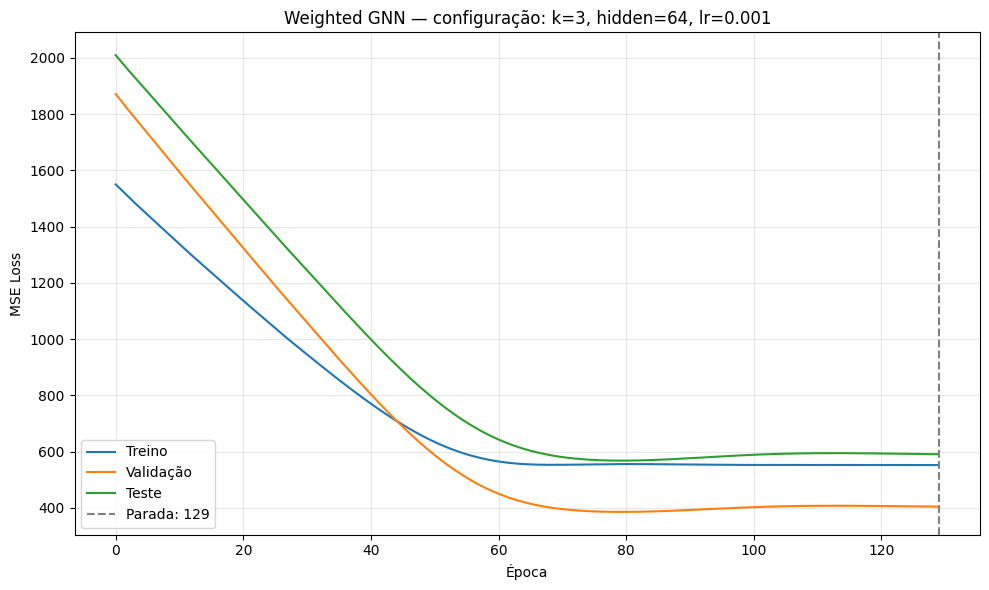

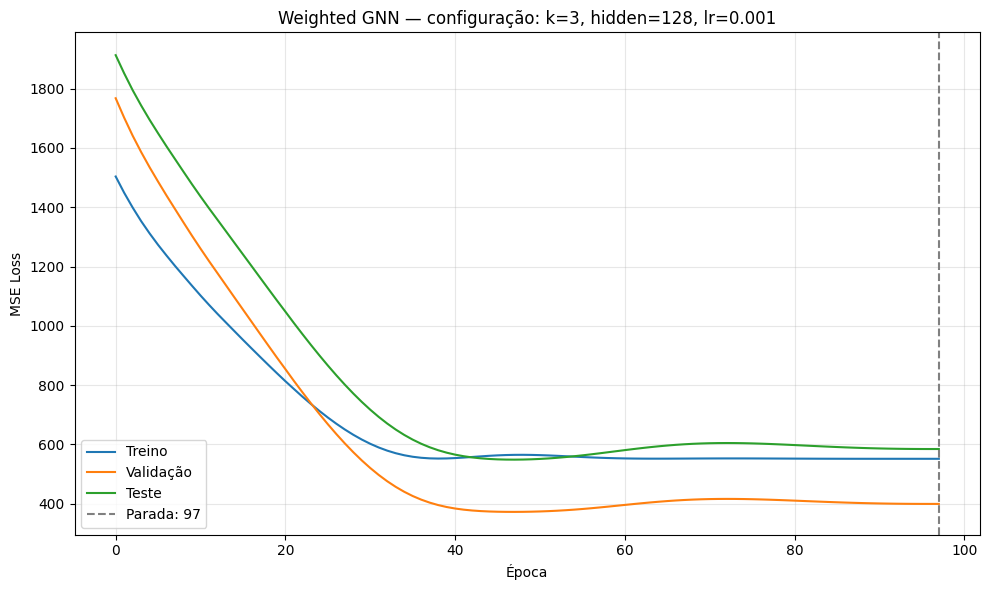

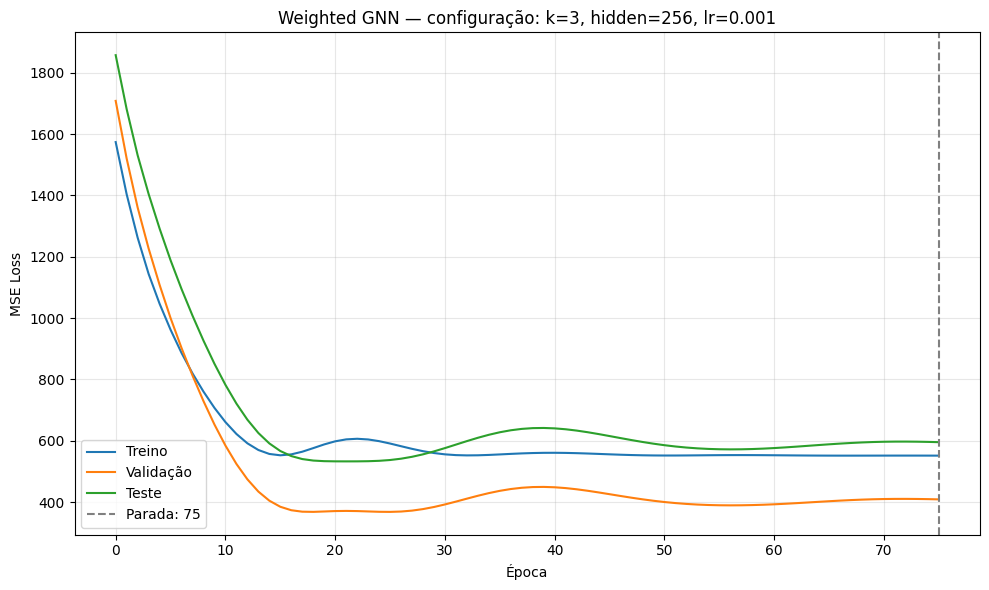

In [32]:
stop_epochs = {
    tuple(row[name] for name in grid_names): row["stop_epoch"]
    for row in grid_rows
}

for config_key, history_run in grid_histories.items():
    config = dict(zip(grid_names, config_key))
    stop_epoch = stop_epochs[config_key]
    epochs_executed = range(len(history_run["train"]))

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(epochs_executed, history_run["train"], label="Treino")
    ax.plot(epochs_executed, history_run["validation"], label="Validação")
    ax.plot(epochs_executed, history_run["test"], label="Teste")
    ax.axvline(
        stop_epoch,
        color="gray",
        linestyle="--",
        label=f"Parada: {stop_epoch}",
    )

    ax.set(
        title=(
            "Weighted GNN — configuração: "
            f"k={config['k']}, hidden={config['hidden_dim']}, "
            f"lr={config['learning_rate']}"
        ),
        xlabel="Época",
        ylabel="MSE Loss",
    )
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

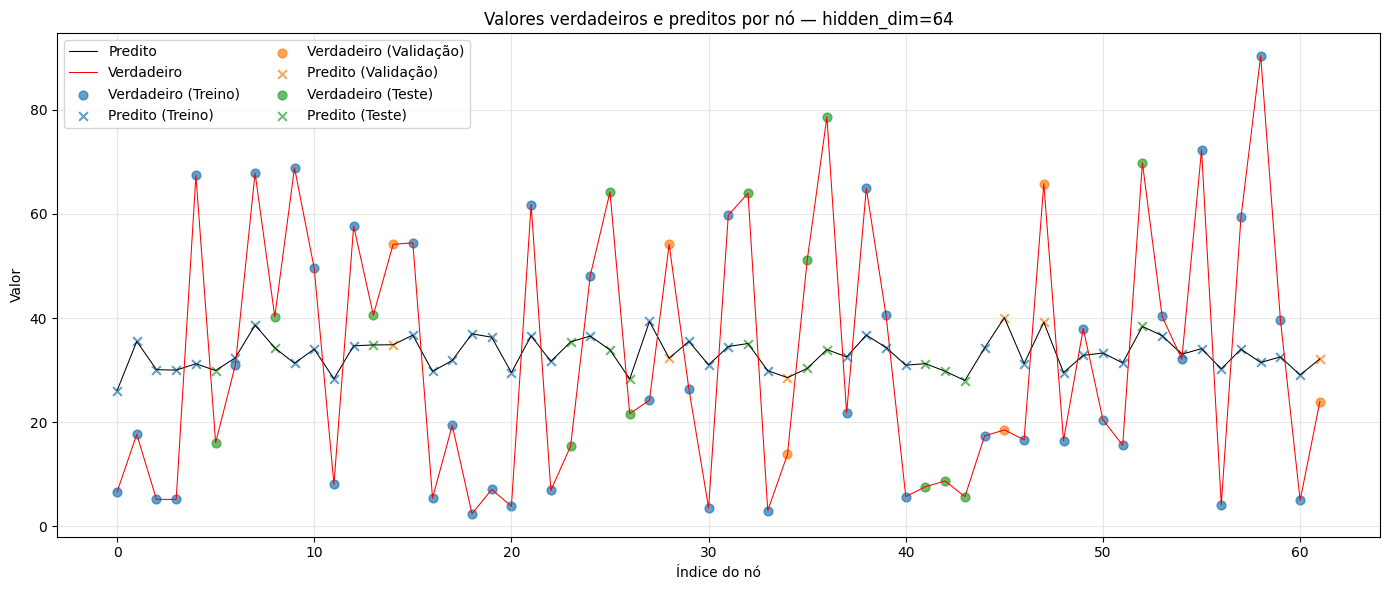

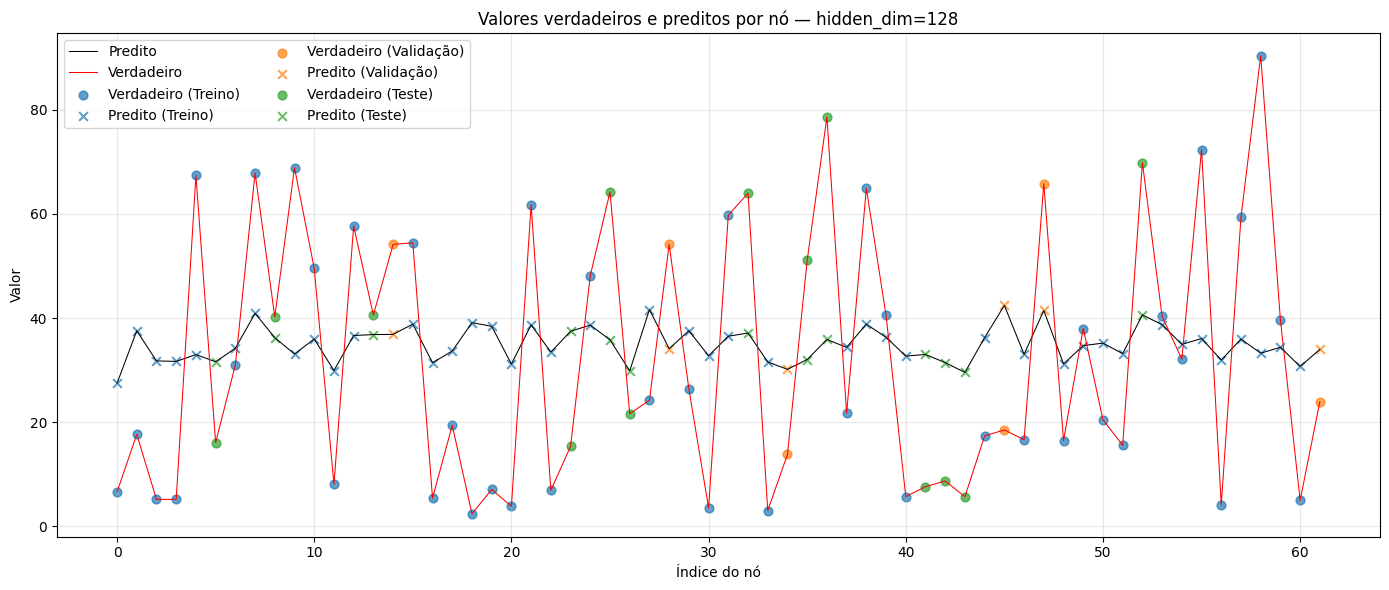

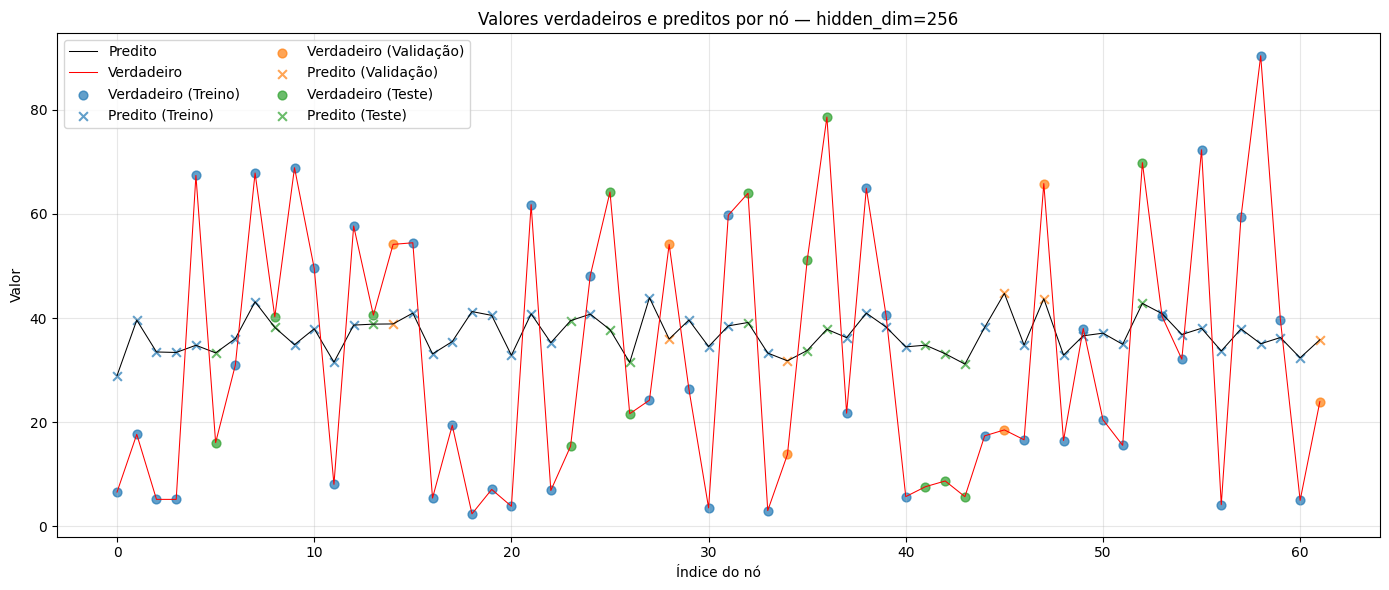

In [33]:
y_true = y.cpu().numpy()
idx_all = np.arange(len(y_true))

split_masks = {
    "Treino": mask_train,
    "Validação": mask_val,
    "Teste": mask_test,
}
colors = {
    "Treino": "tab:blue",
    "Validação": "tab:orange",
    "Teste": "tab:green",
}

for hidden_dim in sorted(grid_predictions_by_hidden_dim):
    y_pred = grid_predictions_by_hidden_dim[hidden_dim]

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(
        idx_all,
        y_pred,
        color="black",
        linestyle="-",
        linewidth=0.75,
        label="Predito",
    )
    ax.plot(
        idx_all,
        y_true,
        color="red",
        linestyle="-",
        linewidth=0.75,
        label="Verdadeiro",
    )

    for label, mask in split_masks.items():
        idx = mask.nonzero(as_tuple=False).flatten().cpu().numpy()
        ax.scatter(
            idx,
            y_true[idx],
            color=colors[label],
            marker="o",
            s=40,
            alpha=0.7,
            label=f"Verdadeiro ({label})",
        )
        ax.scatter(
            idx,
            y_pred[idx],
            color=colors[label],
            marker="x",
            s=40,
            alpha=0.7,
            label=f"Predito ({label})",
        )

    ax.set_xlabel("Índice do nó")
    ax.set_ylabel("Valor")
    ax.set_title(f"Valores verdadeiros e preditos por nó — hidden_dim={hidden_dim}")
    ax.legend(ncol=2, fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [34]:
y_true = y.cpu().numpy()
idx = np.arange(len(y_true))

for hidden_dim in sorted(grid_predictions_by_hidden_dim):
    y_pred = grid_predictions_by_hidden_dim[hidden_dim]
    node_losses = np.square(y_pred - y_true)

    df_node_results = pd.DataFrame(
        {
            "hidden_dim": [hidden_dim] * len(y_true),
            "Índice": idx,
            "Estação": estacoes,
            "Valor verdadeiro": y_true,
            "Valor predito": y_pred,
            "Loss por nó (MSE)": node_losses,
        }
    )

    print(f"hidden_dim = {hidden_dim}")
    display(df_node_results.style.format(precision=6))

hidden_dim = 64


,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,64,0,ACEGUA,6.569386,26.040491,379.123962
1,64,1,ALEGRETE,17.659664,35.525654,319.193573
2,64,2,BAGE,5.164146,30.087057,621.151489
3,64,3,BAGE - CENTRO,5.164146,30.001997,616.918823
4,64,4,BENTO GONCALVES,67.407608,31.220934,1309.475464
5,64,5,CACAPAVA DO SUL,16.067505,29.921822,191.942093
6,64,6,CACHOEIRA DO SUL,30.984879,32.367069,1.910451
7,64,7,CACHOEIRINHA,67.879677,38.668159,853.312744
8,64,8,CAMBARA DO SUL,40.249825,34.270851,35.748123
9,64,9,CAMPO BOM,68.890091,31.313257,1412.018555


hidden_dim = 128


,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,128,0,ACEGUA,6.569386,27.465494,436.647369
1,128,1,ALEGRETE,17.659664,37.566498,396.282013
2,128,2,BAGE,5.164146,31.768751,707.804993
3,128,3,BAGE - CENTRO,5.164146,31.678532,703.012634
4,128,4,BENTO GONCALVES,67.407608,32.980831,1185.203003
5,128,5,CACAPAVA DO SUL,16.067505,31.602617,241.339722
6,128,6,CACHOEIRA DO SUL,30.984879,34.205410,10.371823
7,128,7,CACHOEIRINHA,67.879677,40.902943,727.744202
8,128,8,CAMBARA DO SUL,40.249825,36.234337,16.124142
9,128,9,CAMPO BOM,68.890091,33.087101,1281.854126


hidden_dim = 256


,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,256,0,ACEGUA,6.569386,28.949717,500.879211
1,256,1,ALEGRETE,17.659664,39.603207,481.519043
2,256,2,BAGE,5.164146,33.488251,802.254883
3,256,3,BAGE - CENTRO,5.164146,33.393082,796.872803
4,256,4,BENTO GONCALVES,67.407608,34.777699,1064.710938
5,256,5,CACAPAVA DO SUL,16.067505,33.313740,297.432617
6,256,6,CACHOEIRA DO SUL,30.984879,36.059177,25.748508
7,256,7,CACHOEIRINHA,67.879677,43.136116,612.243774
8,256,8,CAMBARA DO SUL,40.249825,38.206829,4.173831
9,256,9,CAMPO BOM,68.890091,34.890190,1155.993286
